<a href="https://colab.research.google.com/github/arunmatt25/DX703-MilestoneProject/blob/main/Advanced_Machine_Learning_Milestone_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Milestone Two

**Data Preparation and Model Exploration**

**Note: No late assignments accepted, we need the time to grade them!**

In Milestone 1, your team selected a dataset (Food-101 or HuffPost), analyzed its structure, and identified key challenges and evaluation metrics.
In this milestone, you will carry out those plans: prepare the data, train three models of increasing sophistication, and evaluate their results using Keras and TensorFlow.
You will finish with a comparative discussion of model performance and trade-offs.


### Submission Guidelines

* Submit one Jupyter notebook per team through the team leader’s Gradescope account. **Include all team members names at the top of the notebook.**
* Include all code, plots, and answers inline below.
* Ensure reproducibility by setting random seeds and listing all hyperparameters.
* Document any AI tools used, as required by the CDS policy.


## Problem 1 – Data Preparation and Splits (20 pts)

### Goals

Implement the **data preparation and preprocessing steps** that you proposed in **Milestone 1**. You’ll clean, normalize, and split your data so that it’s ready for modeling and reproducible fine-tuning.

### Steps to Follow

1. **Load your chosen dataset**

   * Use `datasets.load_dataset()` from **Hugging Face** to load **Food-101** or **HuffPost**.
   * Display basic information (e.g., number of samples, feature names, example entries).

2. **Apply cleaning and normalization**

   * **Images:**

     * Ensure all images are in RGB format.
     * Resize or crop to a consistent shape (e.g., `224 × 224`).
     * Drop or fix any corrupted files.
   * **Text:**

     * Concatenate headline + summary (for HuffPost).
     * Strip whitespace, convert to lowercase if appropriate, and remove empty samples.
     * Optionally remove duplicates or extremely short entries.

3. **Standardize or tokenize the inputs**

   * **Images:**

     * Normalize pixel values (e.g., divide by 255.0).
     * Define a minimal augmentation pipeline (e.g., random flip, crop, or rotation).
   * **Text:**

     * Create a tokenizer or `TextVectorization` layer.
     * Set a target `max_length` based on your analysis from Milestone 1 (e.g., 95th percentile).
     * Apply padding/truncation and build tensors for input + labels.

4. **Handle dataset-specific challenges**

   * If you identified **class imbalance**, compute label counts and, if needed, create a dictionary of `class_weights`.
   * If you noted **length or size variance**, verify that your truncation or resizing works as intended.
   * If you planned **noise filtering**, include the cleaning step and briefly explain your criteria (e.g., remove items with missing text or unreadable images).

5. **Create reproducible splits**

   * Split your cleaned dataset into **train**, **validation**, and **test** subsets (e.g., 80 / 10 / 10).
   * Use a fixed random seed for reproducibility (`random_seed = 42`).
   * Use **stratified splits**  (e.g., with `train_test_split` and `stratify = labels`).
   * Display the size of each subset.

6. **Document your pipeline**

   * Summarize your preprocessing steps clearly in Markdown or code comments.
   * Save or display a few representative examples after preprocessing to confirm the transformations are correct.




In [3]:
from datasets import load_dataset
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 1. Load the dataset
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

# 2. Apply cleaning and normalization
df = huff_all.to_pandas()
df["text"] = df["headline"].fillna('') + " " + df["short_description"].fillna('')
df["text"] = df["text"].str.strip() # Strip whitespace
df["text"] = df["text"].str.lower() # Convert to lowercase
df = df[df["text"].str.len() > 0]# Remove empty samples
df = df[df["text"].str.split().str.len() > 3]  # Remove very short entries
df = df.drop_duplicates(subset="text") # Remove duplicates

# 3. Standardize or tokenize the inputs (for max_length)
word_counts = df["text"].str.split().apply(len)
max_length = int(np.percentile(word_counts, 95))

# 4. Define num_classes
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["category"])
num_classes = len(label_encoder.classes_)

print(f"num_classes defined as: {num_classes}")
print(f"max_length defined as: {max_length}")

News_Category_Dataset_v2.json:   0%|          | 0.00/83.9M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

num_classes defined as: 41
max_length defined as: 56


In [4]:
# Your code here; add as many cells as you need but make it clear what the structure is.
from datasets import load_dataset, DatasetDict
from datasets.features import ClassLabel
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

print(huff_all)
print("Columns:", huff_all.column_names)
print("Total rows:", len(huff_all))





Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200853


In [5]:
df = huff_all.to_pandas()
df["text"] = df["headline"].fillna('') + " " + df["short_description"].fillna('')
df["text"] = df["text"].str.strip() # Strip whitespace
df["text"] = df["text"].str.lower() # Convert to lowercase
df = df[df["text"].str.len() > 0]# Remove empty samples
df = df[df["text"].str.split().str.len() > 3]  # Remove very short entries
df = df.drop_duplicates(subset="text") # Remove duplicates

df.head()


,category,headline,authors,link,short_description,date,text
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,Melissa Jeltsen,https://www.huffingtonpost.com/entry/texas-ama...,She left her husband. He killed their children...,2018-05-26,there were 2 mass shootings in texas last week...
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Andy McDonald,https://www.huffingtonpost.com/entry/will-smit...,Of course it has a song.,2018-05-26,will smith joins diplo and nicky jam for the 2...
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,Ron Dicker,https://www.huffingtonpost.com/entry/hugh-gran...,The actor and his longtime girlfriend Anna Ebe...,2018-05-26,hugh grant marries for the first time at age 5...
3,ENTERTAINMENT,Jim Carrey Blasts 'Castrato' Adam Schiff And D...,Ron Dicker,https://www.huffingtonpost.com/entry/jim-carre...,The actor gives Dems an ass-kicking for not fi...,2018-05-26,jim carrey blasts 'castrato' adam schiff and d...
4,ENTERTAINMENT,Julianna Margulies Uses Donald Trump Poop Bags...,Ron Dicker,https://www.huffingtonpost.com/entry/julianna-...,"The ""Dietland"" actress said using the bags is ...",2018-05-26,julianna margulies uses donald trump poop bags...


In [6]:


# Count words in each cleaned text sample
word_counts = df["text"].str.split().apply(len)

# Set max_length to the 95th percentile
max_length = int(np.percentile(word_counts, 95))

print("95th percentile max_length:", max_length)
print("Median length:", int(np.median(word_counts)))
print("Max length:", word_counts.max())

95th percentile max_length: 56
Median length: 28
Max length: 245


In [7]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["category"])

num_classes = len(label_encoder.classes_)
print("Number of classes:", num_classes)

Number of classes: 41


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)
print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))


Train size: 159914
Validation size: 19989
Test size: 19990


In [9]:


# Vocabulary size can be adjusted
max_tokens = 20000

vectorizer = TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=max_length
)

# Adapt ONLY on training text
vectorizer.adapt(X_train.values)

In [10]:
X_train_vec = vectorizer(np.array(X_train)).numpy()
X_val_vec = vectorizer(np.array(X_val)).numpy()
X_test_vec = vectorizer(np.array(X_test)).numpy()

# Convert labels to numpy arrays
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

print("X_train shape:", X_train_vec.shape)
print("X_val shape:", X_val_vec.shape)
print("X_test shape:", X_test_vec.shape)
print("y_train shape:", y_train.shape)

X_train shape: (159914, 56)
X_val shape: (19989, 56)
X_test shape: (19990, 56)
y_train shape: (159914,)


In [11]:
batch_size = 32

train_ds = tf.data.Dataset.from_tensor_slices((X_train_vec, y_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val_vec, y_val)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test_vec, y_test)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

print(train_ds)
print(val_ds)
print(test_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 56), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 56), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 56), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


Class distribution:
category
POLITICS          32659
WELLNESS          17820
ENTERTAINMENT     16032
TRAVEL             9869
STYLE & BEAUTY     9511
PARENTING          8649
HEALTHY LIVING     6626
QUEER VOICES       6304
FOOD & DRINK       6225
BUSINESS           5916
COMEDY             5052
SPORTS             4876
BLACK VOICES       4517
HOME & LIVING      4160
PARENTS            3893
THE WORLDPOST      3664
WEDDINGS           3651
IMPACT             3449
DIVORCE            3422
CRIME              3395
WOMEN              3392
MEDIA              2806
WEIRD NEWS         2664
GREEN              2609
WORLDPOST          2558
RELIGION           2521
STYLE              2244
SCIENCE            2177
WORLD NEWS         2176
TASTE              2084
TECH               2033
MONEY              1706
ARTS               1497
GOOD NEWS          1392
FIFTY              1387
ARTS & CULTURE     1338
ENVIRONMENT        1322
COLLEGE            1139
LATINO VOICES      1129
CULTURE & ARTS     1029
EDUCATION  

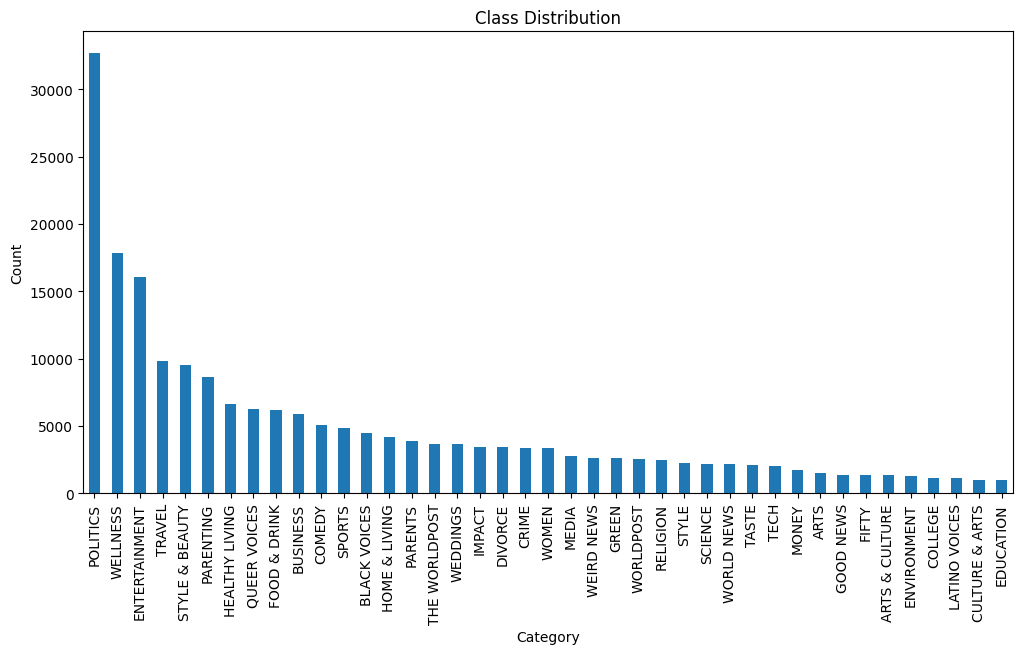


Class weights:
{np.int64(0): np.float64(3.255710737407875), np.int64(1): np.float64(3.645178937770686), np.int64(2): np.float64(1.079231174160109), np.int64(3): np.float64(0.8240738354985494), np.int64(4): np.float64(4.281384701882145), np.int64(5): np.float64(0.9651921463535348), np.int64(6): np.float64(1.4360609217285103), np.int64(7): np.float64(4.739175532703079), np.int64(8): np.float64(1.4245220830586685), np.int64(9): np.float64(4.875426829268292), np.int64(10): np.float64(0.3041201920791138), np.int64(11): np.float64(3.6865231223200703), np.int64(12): np.float64(3.513821138211382), np.int64(13): np.float64(0.7832010970712117), np.int64(14): np.float64(3.5012041861890792), np.int64(15): np.float64(1.8688746829969498), np.int64(16): np.float64(0.7357746582559204), np.int64(17): np.float64(1.1719776031894935), np.int64(18): np.float64(1.413679399570364), np.int64(19): np.float64(4.319315020392729), np.int64(20): np.float64(1.7373458634363625), np.int64(21): np.float64(2.857393013

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

# 1. Check class imbalance

label_counts = df["category"].value_counts().sort_values(ascending=False)
print("Class distribution:")
print(label_counts)

print("\nLeast frequent classes:")
print(df["category"].value_counts().sort_values().head(10))

plt.figure(figsize=(12, 6))
df["category"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()


# 2. Compute class weights

classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, class_weights_array))

print("\nClass weights:")
print(class_weights)


# 3. Verify padding / truncation

print("\nChosen max_length:", max_length)
print("Vectorized training shape:", X_train_vec.shape)
print("Vectorized validation shape:", X_val_vec.shape)
print("Vectorized test shape:", X_test_vec.shape)

print("Example tokenized sequence length:", len(X_train_vec[0]))
print("First tokenized sample:", X_train_vec[0][:30])

train_lengths = X_train.str.split().apply(len)
pct_truncated = (train_lengths > max_length).mean() * 100
print(f"Percentage of training samples longer than max_length: {pct_truncated:.2f}%")


# 4. quantify cleaning impact

df_raw = huff_all.to_pandas().copy()

initial_count = len(df_raw)

df_clean = df_raw.copy()
df_clean["text"] = df_clean["headline"].fillna('') + " " + df_clean["short_description"].fillna('')
df_clean["text"] = df_clean["text"].str.strip().str.lower()

after_empty_filter = len(df_clean[df_clean["text"].str.len() > 0])

df_clean = df_clean[df_clean["text"].str.len() > 0]
df_clean = df_clean[df_clean["text"].str.split().str.len() > 3]
after_short_filter = len(df_clean)

df_clean = df_clean.drop_duplicates(subset="text")
final_count = len(df_clean)

print("\nCleaning summary:")
print("Initial samples:", initial_count)
print("After removing empty samples:", after_empty_filter)
print("After removing very short samples:", after_short_filter)
print("After removing duplicates:", final_count)
print("Total removed:", initial_count - final_count)

### Graded Questions (5 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

1. **Data Loading and Cleaning:**
   Describe how you loaded your dataset and the key cleaning steps you implemented (e.g., handling missing data, normalizing formats, or removing duplicates).



1.1. **Your answer here:**
I startedd by  loading the HuffPost dataset from a JSON file hosted on Hugging Face using the datasets library, then converted it to a pandas DataFrame for easier preprocessing. To create a richer text feature for classification, I concatenated the headline and short_description fields into a single text column. Missing text values were handled by replacing them with empty strings before concatenation. I then cleaned the combined text by stripping extra whitespace and converting all text to lowercase to make formatting more consistent across samples. Finally, I removed empty entries, filtered out extremely short samples with very little semantic content, and dropped duplicate text records to reduce noise and redundancy in the dataset.




2. **Preprocessing and Standardization:**
   Summarize your preprocessing pipeline. Include any normalization, tokenization, resizing, or augmentation steps, and explain why each was necessary for your dataset.
  

1.2. **Your answer here:**
My preprocessing pipeline was designed to prepare the text for deep learning while preserving as much useful information as possible. After cleaning and combining the text fields, I encoded the category labels into numeric form using LabelEncoder. For the text inputs, I used Keras’s TextVectorization layer to tokenize the documents and convert them into integer sequences. I selected a fixed max_length based on the 95th percentile of document lengths from the cleaned dataset, which allowed me to retain most samples while limiting the effect of unusually long outliers. The vectorization layer applied padding and truncation automatically so that every input had the same shape, which is required for efficient model training.


3. **Train/Validation/Test Splits:**
   Explain how you divided your data into subsets, including the split ratios, random seed, and any stratification or leakage checks you used to verify correctness.


1.3. **Your answer here:**

I divided the dataset into training, validation, and test subsets using a two-step stratified split. First, I split the data into 80% training and 20% temporary data, then split the temporary portion evenly into 10% validation and 10% test. I used a fixed random_state=42 to make the split reproducible. Stratification was applied in both stages using the encoded labels so that each subset preserved the overall class distribution of the full dataset

4. **Class Distribution and Balance:**
   Report your label counts and describe any class imbalances you observed. If applicable, explain how you addressed them (e.g., weighting, oversampling, or data augmentation).


1.4. **Your answer here:**
The class distribution showed that the HuffPost dataset is not perfectly balanced, with some categories containing substantially more examples than others.To address this, I computed label counts and then used the training labels to generate class weights with compute class weight. These weights can be passed into model training so that errors on underrepresented classes receive more importance


## Problem 2 – Baseline Model (20 pts)

### Goal

Build and train a **simple, fully functional baseline model** to establish a reference level of performance for your dataset.
This baseline will help you evaluate whether later architectures and fine-tuning steps actually improve results.


### Steps to Follow

1. **Construct a baseline model**

   * **Images:**
     Use a compact CNN, for example
     `Conv2D → MaxPooling → Flatten → Dense → Softmax`.
   * **Text:**
     Use a small embedding-based classifier such as
     `Embedding → GlobalAveragePooling → Dense → Softmax`.
   * Keep the model small enough to train in minutes on Colab.

2. **Compile the model**

   * Optimizer: `Adam` or `AdamW`.
   * Loss: `categorical_crossentropy` (for multi-class).
   * Metrics: at least `accuracy`; add `F1` if appropriate.

3. **Train and validate**

   * Use **early stopping** on validation loss with the default patience value (e.g., 5 epochs).
   * Record number of epochs trained and total runtime.

4. **Visualize results**

   * Plot **training vs. validation accuracy and loss**.
   * Carefully observe: does the model underfit, overfit, or generalize reasonably?

5. **Report baseline performance**

   * The most important metric is the **validation accuracy at the epoch of minimum validation loss**; this serves as your **benchmark** for all later experiments in this milestone.
   * Evaluate on the **test set** and record final metrics.

In [ ]:
# Your code here; add as many cells as you need but make it clear what the structure is.
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout

# Get vocabulary size from the trained TextVectorization layer
vocab_size = len(vectorizer.get_vocabulary())

# Build a small baseline model
baseline_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_length),
    GlobalAveragePooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

baseline_model.summary()

In [ ]:
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
import time
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping callback
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Track runtime
start_time = time.time()

history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print(f"Training runtime: {training_time:.2f} seconds")
print(f"Epochs trained: {len(history.history['loss'])}")

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Baseline Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Baseline Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:


best_epoch = int(np.argmin(history.history["val_loss"]))
best_val_loss = history.history["val_loss"][best_epoch]
best_val_acc = history.history["val_accuracy"][best_epoch]

print(f"Best Epoch (min val loss): {best_epoch + 1}")
print(f"Validation Loss @ Best Epoch: {best_val_loss:.4f}")
print(f"Validation Accuracy @ Best Epoch: {best_val_acc:.4f}")
# Find the epoch with minimum validation loss
best_epoch = np.argmin(history.history["val_loss"])
best_val_loss = history.history["val_loss"][best_epoch]
best_val_accuracy = history.history["val_accuracy"][best_epoch]

print(f"Best epoch (minimum validation loss): {best_epoch + 1}")
print(f"Validation loss at best epoch: {best_val_loss:.4f}")
print(f"Validation accuracy at best epoch: {best_val_accuracy:.4f}")

# Optional: summarize all epochs in a table
history_df = pd.DataFrame(history.history)
history_df.index = history_df.index + 1
history_df.index.name = "epoch"
history_df.head(10)

In [ ]:
# Improved plots ( Added by Arun)
import numpy as np

best_epoch = int(np.argmin(history.history["val_loss"]))
best_val_loss = history.history["val_loss"][best_epoch]
best_val_acc = history.history["val_accuracy"][best_epoch]

print(f"Best Epoch (min val loss): {best_epoch + 1}")
print(f"Validation Loss @ Best Epoch: {best_val_loss:.4f}")
print(f"Validation Accuracy @ Best Epoch: {best_val_acc:.4f}")

# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.axvline(best_epoch, color="red", linestyle="--", label="Best Epoch")
plt.scatter(best_epoch, best_val_acc, color="red")
plt.title("Baseline Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# loss plot
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.axvline(best_epoch, color="red", linestyle="--", label="Best Epoch")
plt.scatter(best_epoch, best_val_loss, color="red")
plt.title("Baseline Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [ ]:
#this is for test split

test_loss, test_accuracy = baseline_model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Get predictions
y_pred_probs = baseline_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)

print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))



### Graded Questions (5 pts each)

1. **Model Architecture:**
   Describe your baseline model and justify why this structure suits your dataset.

2.1. **Your answer here:**

The baseline model is a simple embedding-based neural network consisting of an Embedding layer, followed by GlobalAveragePooling1D, a dense hidden layer with ReLU activation, dropout for regularization, and a final softmax output layer for multi-class classification. This structure is well-suited for the dataset because it efficiently converts tokenized text into dense representations while keeping computational cost low.

2. **Training Behavior:**
   Summarize the model’s training and validation curves. What trends did you observe?

2.2. **Your answer here:**

The training and validation curves showed steady improvement in both accuracy and loss during the initial epochs, indicating that the model was learning meaningful patterns from the data. Over time, the validation performance began to plateau while training accuracy continued to improve slightly, suggesting mild overfitting. However, early stopping helped prevent excessive overfitting by halting training once validation loss stopped improving. Overall, the model demonstrated reasonable generalization but with limited capacity.

  3. **Baseline Metrics:**
   Report validation and test metrics. What does this performance tell you about dataset difficulty?

2.3. **Your answer here:**

The baseline model achieved a validation accuracy of 0.5265 at the epoch with the minimum validation loss (epoch 6), with a validation loss of 1.7705. On the test set, the model achieved a test accuracy of 0.5363 and a test loss of 1.7171. These results indicate that the dataset is moderately challenging, likely due to the large number of classes and overlapping language between categories. The close alignment between validation and test accuracy suggests that the model generalizes reasonably well, though its performance remains limited.



  4. **Reflection:**
   What are the main limitations of your baseline? Which specific improvements (depth, regularization, pretraining) would you try next?
  

2.4. **Your answer here:**
The main limitation of the baseline model is its simplicity, particularly the use of average pooling, which loses important word order and contextual information. This restricts the model’s ability to capture nuanced semantic differences between categories

abou improvemnt i would try to  improve performance, I would explore deeper architectures such as adding more dense layers or using sequence models like Bidirectional. Additionally, stronger regularization and hyperparameter tuning could improve generalization. The most promising improvement would be using a pretrained transformer model such as BERT, which can better capture contextual relationships in text.


## Problem 3 – Custom (Original) Model (20 pts)

### Goal

Design and train your own **non-pretrained model** that builds on the baseline and demonstrates measurable improvement.
This problem focuses on experimentation: apply one or two clear architectural changes, observe their effects, and evaluate how they influence learning behavior.


### Steps to Follow

1. **Modify or extend your baseline architecture**

   * Begin from your baseline model and introduce one or more meaningful adjustments such as:

     * Adding **dropout** or **batch normalization** for regularization.
     * Increasing **depth** (extra convolutional or dense layers).
     * Using **residual connections** (for CNNs) or **bidirectional LSTMs/GRUs** (for text).
     * Trying alternative activations like `ReLU`, `LeakyReLU`, or `GELU`.
   * Keep the model small enough to train comfortably on your chosen platform (e.g., Colab)

2. **Observe what specific limitations you want to address**

   * Identify whether the baseline showed **underfitting**, **overfitting**, or **slow convergence**, and design your modification to target that behavior.
   * Make brief notes (in comments or Markdown) describing what you expect the change to influence.

3. **Train and evaluate under the same conditions**

   * Use the **same data splits**, **random seed**, and **metrics** as in Problem 2.
   * Apply **early stopping** on validation loss.
   * Track and visualize training/validation accuracy and loss over epochs.

4. **Compare outcomes to the baseline**

   * Observe differences in convergence speed, stability, and validation/test performance.
   * Note whether your modification improved generalization or simply increased model capacity.

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

# Build custom non-pretrained model
custom_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length),
    Bidirectional(LSTM(64)),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

custom_model.summary()

In [ ]:
from tensorflow.keras.optimizers import Adam

custom_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
import time
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping callback
custom_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Track runtime
start_time = time.time()

custom_history = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[custom_early_stopping],
    verbose=1
)

end_time = time.time()
custom_training_time = end_time - start_time

print(f"Custom model training runtime: {custom_training_time:.2f} seconds")
print(f"Epochs trained: {len(custom_history.history['loss'])}")

In [ ]:


# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(custom_history.history["accuracy"], label="Training Accuracy")
plt.plot(custom_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Custom Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(8, 5))
plt.plot(custom_history.history["loss"], label="Training Loss")
plt.plot(custom_history.history["val_loss"], label="Validation Loss")
plt.title("Custom Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:


# Find best epoch based on validation loss
custom_best_epoch = np.argmin(custom_history.history["val_loss"])
custom_best_val_loss = custom_history.history["val_loss"][custom_best_epoch]
custom_best_val_accuracy = custom_history.history["val_accuracy"][custom_best_epoch]

print(f"Best epoch (minimum validation loss): {custom_best_epoch + 1}")
print(f"Validation loss at best epoch: {custom_best_val_loss:.4f}")
print(f"Validation accuracy at best epoch: {custom_best_val_accuracy:.4f}")

In [ ]:
# Evaluate custom model on test set
custom_test_loss, custom_test_accuracy = custom_model.evaluate(test_ds)

print(f"Custom Test Loss: {custom_test_loss:.4f}")
print(f"Custom Test Accuracy: {custom_test_accuracy:.4f}")

### Graded Questions (5 pts each)

1. **Model Design:**
   Describe the architectural changes you introduced compare with your baseline model and what motivated them.

3.1. **Your answer here:**
The custom model extends the baseline by replacing the GlobalAveragePooling1D layer with a Bidirectional LSTM to better capture sequential relationships in the text. While the baseline model averaged token embeddings and lost word-order information, the Bidirectional LSTM processes the sequence in both forward and backward directions, allowing it to learn contextual dependencies between words. Additionally, the embedding dimension was increased and dropout layers were retained to improve representational capacity and control overfitting.


2. **Training Results:**
   Present key validation and test metrics. Did your modifications improve performance?

3.2. **Your answer here:**

The custom model achieved a validation accuracy of 0.5178 at the epoch with the lowest validation loss (epoch 3), with a validation loss of 1.8013. On the test set, it achieved an accuracy of 0.5231 and a loss of 1.7525. Compared to the baseline model (validation accuracy 0.5265, test accuracy 0.5363), the custom model did not improve performance and showed slightly lower accuracy on both validation and test sets.

3. **Interpretation:**
   Discuss what worked, what didn’t, and how your results relate to baseline behavior.

3.3. **Your answer here:**
Although the custom model introduced a more expressive architecture through the Bidirectional LSTM, it did not lead to improved performance. One possible reason is that the increased complexity caused the model to overfit or converge too quickly, as indicated by the best validation performance occurring early at epoch 3. Additionally, the dataset may not require complex sequence modeling for this task, and the simpler averaging approach used in the baseline may have been sufficient to capture the dominant patterns. This suggests that adding complexity does not always guarantee better results and must be matched to the dataset characteristics.


4. **Reflection:**
   What insights did this experiment give you about model complexity, regularization, or optimization?

3.4. **Your answer here:**
Although the custom model introduced a more expressive architecture through the Bidirectional LSTM, it did not lead to improved performance. One possible reason is that the increased complexity caused the model to overfit or converge too quickly, as indicated by the best validation performance occurring early at epoch 3. Additionally, the dataset may not require complex sequence modeling for this task, and the simpler averaging approach used in the baseline may have been sufficient to capture the dominant patterns. This suggests that adding complexity does not always guarantee better results and must be matched to the dataset characteristics.


## Problem 4 – Pretrained Model (Transfer Learning) (20 pts)

### Goal

Apply **transfer learning** to see how pretrained knowledge improves accuracy, convergence speed, and generalization.
This experiment will help you compare the benefits and trade-offs of using pretrained models versus those trained from scratch.


### Steps to Follow

1. **Select a pretrained architecture**

   * **Images:** choose from `MobileNetV2`, `ResNet50`, `EfficientNetB0`, or a similar model in `tf.keras.applications`.
   * **Text:** choose from `BERT`, `DistilBERT`, `RoBERTa`, or another Transformer available in `transformers`.

2. **Adapt the model for your dataset**

   * Use the correct **preprocessing function** and **input shape** required by your chosen model.
   * Replace the top layer with your own **classification head** (e.g., `Dense(num_classes, activation='softmax')`).

3. **Apply transfer learning**

   * Choose an appropriate **training strategy** for your pretrained model. Options include:

     * **Freezing** the pretrained base and training only a new classification head.
     * **Partially fine-tuning** selected upper layers of the base model.
     * **Full fine-tuning** (all layers trainable) with a reduced learning rate.
   * Adjust your learning rate schedule to match your strategy (e.g., smaller LR for fine-tuning).
   * Observe how your chosen approach affects **validation loss**, **training time**, and **model stability**.

4. **Train and evaluate under consistent conditions**

   * Use the same **splits**, **metrics**, and **evaluation protocol** as in earlier problems.
   * Record training duration, validation/test performance, and any resource constraints (GPU memory, runtime).

5. **Compare and analyze**

   * Observe how transfer learning changes both **performance** and **efficiency** relative to your baseline and custom models.
   * Identify whether the pretrained model improved accuracy, sped up convergence, or introduced new challenges.


In [12]:
from transformers import AutoTokenizer

model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# Use the same cleaned text splits from earlier
X_train_list = X_train.tolist()
X_val_list = X_val.tolist()
X_test_list = X_test.tolist()

# Tokenize
train_encodings = tokenizer(
    X_train_list,
    truncation=True,
    padding=True,
    max_length=max_length
)

val_encodings = tokenizer(
    X_val_list,
    truncation=True,
    padding=True,
    max_length=max_length
)

test_encodings = tokenizer(
    X_test_list,
    truncation=True,
    padding=True,
    max_length=max_length
)

In [25]:
import tensorflow as tf

train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    y_train
)).batch(16)

val_dataset = tf.data.Dataset.from_tensor_slices((
    dict(val_encodings),
    y_val
)).batch(16)

test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    y_test
)).batch(16)

In [15]:
from transformers import TFAutoModelForSequenceClassification

transfer_model = TFAutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_classes,
    use_safetensors=False
)


tf_model.h5:   0%|          | 0.00/363M [00:00<?, ?B/s]

Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['vocab_layer_norm', 'vocab_transform', 'activation_13', 'vocab_projector']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['dropout_39', 'pre_classifier', 'classifier']
You should probably TRAIN this model on a down-stream task to be able to use i

In [24]:

from tf_keras.optimizers import Adam
from tf_keras.losses import SparseCategoricalCrossentropy

transfer_model.compile(
    optimizer=Adam(learning_rate=2e-5),
    loss=SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [26]:
from tf_keras.optimizers import Adam
from tf_keras.callbacks import EarlyStopping
import time

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

start_time = time.time()

transfer_history = transfer_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,
    callbacks=[early_stopping],
    verbose=1
)

end_time = time.time()
transfer_training_time = end_time - start_time

print(f"Training runtime: {transfer_training_time:.2f} seconds")
print(f"Epochs trained: {len(transfer_history.history['loss'])}")

Epoch 1/5
9995/9995 [==============================] - 1141s 112ms/step - loss: 1.3029 - accuracy: 0.6410 - val_loss: 1.0578 - val_accuracy: 0.6898
Epoch 2/5
9995/9995 [==============================] - 1099s 110ms/step - loss: 0.8606 - accuracy: 0.7443 - val_loss: 1.0480 - val_accuracy: 0.7009
Epoch 3/5
9995/9995 [==============================] - 1096s 110ms/step - loss: 0.6233 - accuracy: 0.8109 - val_loss: 1.1197 - val_accuracy: 0.6995
Epoch 4/5
9995/9995 [==============================] - 1096s 110ms/step - loss: 0.4392 - accuracy: 0.8650 - val_loss: 1.2482 - val_accuracy: 0.6911
Training runtime: 4432.36 seconds
Epochs trained: 4


In [27]:
import numpy as np

best_epoch = int(np.argmin(transfer_history.history["val_loss"]))
best_val_loss = transfer_history.history["val_loss"][best_epoch]
best_val_acc = transfer_history.history["val_accuracy"][best_epoch]

print(f"Best epoch (min val loss): {best_epoch + 1}")
print(f"Validation loss @ best epoch: {best_val_loss:.4f}")
print(f"Validation accuracy @ best epoch: {best_val_acc:.4f}")

Best epoch (min val loss): 2
Validation loss @ best epoch: 1.0480
Validation accuracy @ best epoch: 0.7009


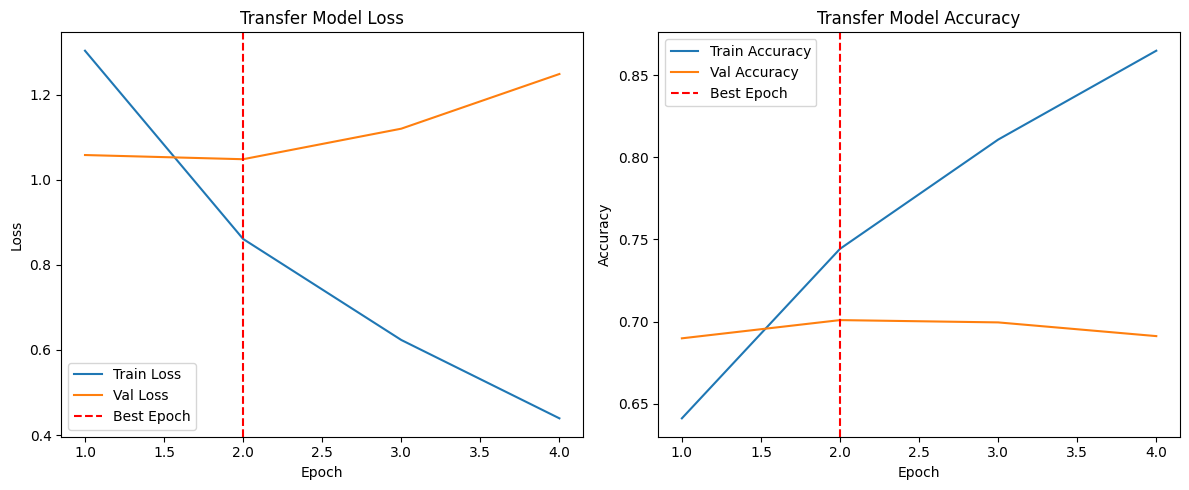

In [28]:
import matplotlib.pyplot as plt

epochs = range(1, len(transfer_history.history["loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, transfer_history.history["loss"], label="Train Loss")
plt.plot(epochs, transfer_history.history["val_loss"], label="Val Loss")
plt.axvline(best_epoch + 1, color="red", linestyle="--", label="Best Epoch")
plt.title("Transfer Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, transfer_history.history["accuracy"], label="Train Accuracy")
plt.plot(epochs, transfer_history.history["val_accuracy"], label="Val Accuracy")
plt.axvline(best_epoch + 1, color="red", linestyle="--", label="Best Epoch")
plt.title("Transfer Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [29]:
test_results = transfer_model.evaluate(test_dataset, verbose=1)
print("Test results:", test_results)

1250/1250 [==============================] - 45s 36ms/step - loss: 1.0178 - accuracy: 0.7061
Test results: [1.0177642107009888, 0.7060530185699463]


In [30]:
from sklearn.metrics import classification_report

pred_logits = transfer_model.predict(test_dataset).logits
y_pred = np.argmax(pred_logits, axis=1)

print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

1250/1250 [==============================] - 46s 36ms/step
                precision    recall  f1-score   support

          ARTS       0.56      0.48      0.52       149
ARTS & CULTURE       0.56      0.55      0.56       134
  BLACK VOICES       0.61      0.50      0.55       452
      BUSINESS       0.72      0.45      0.56       592
       COLLEGE       0.56      0.52      0.54       114
        COMEDY       0.47      0.59      0.53       506
         CRIME       0.67      0.67      0.67       340
CULTURE & ARTS       0.67      0.46      0.54       103
       DIVORCE       0.84      0.80      0.82       342
     EDUCATION       0.50      0.56      0.53       100
 ENTERTAINMENT       0.69      0.83      0.76      1604
   ENVIRONMENT       0.66      0.48      0.55       132
         FIFTY       0.53      0.36      0.43       138
  FOOD & DRINK       0.73      0.85      0.79       623
     GOOD NEWS       0.48      0.33      0.39       139
         GREEN       0.47      0.59      0.5

### Graded Questions (5 pts each)

1. **Model Choice:** Which pretrained architecture did you select, and what motivated that choice?

4.1. **Your answer here:**
I selected DistilBERT (distilbert-base-uncased) as the pretrained architecture for this task. The primary motivation was that DistilBERT provides strong contextual language representations while being significantly smaller and faster than full BERT, making it well-suited for efficient training in a notebook environment. Since the HuffPost dataset involves nuanced text classification across many categories, a Transformer-based model is more effective than traditional embedding approaches because it captures word context and semantics more accurately. Additionally, DistilBERT integrates seamlessly with the Hugging Face Transformers library and supports straightforward fine-tuning, making it a practical and high-performing choice for this problem.



2. **Fine-Tuning Plan:** Describe your fine-tuning strategy and why you chose it.

4.2. **Your answer here:**
I fine-tuned the DistilBERT model by updating all layers (full fine-tuning) while using a small learning rate (2e-5) to preserve the pretrained knowledge and avoid large weight updates. This approach allows the model to adapt its contextual representations to the specific characteristics of the HuffPost dataset while maintaining stability during training. I used early stopping based on validation loss to prevent overfitting, as the model showed rapid convergence within the first few epochs. This strategy was chosen because full fine-tuning typically yields better performance than freezing layers for text classification tasks, especially when the dataset is moderately sized, while the small learning rate and early stopping help control overfitting and ensure generalization.


3. **Performance:** Report key metrics and compare them with your baseline and custom models.

4.3. **Your answer here:**
The pretrained DistilBERT model achieved a best validation accuracy of about 0.70 at the epoch of minimum validation loss (around epoch 2) and a test accuracy of 0.706, with a macro F1 of 0.61 and a weighted F1 of 0.70. The classification report showed especially strong performance on larger, well-defined categories such as POLITICS, TRAVEL, and STYLE & BEAUTY, while smaller or more ambiguous classes remained more difficult. Compared with my simpler baseline and custom text models, the transfer-learning model provided stronger contextual understanding and more balanced performance across many categories, though it also began to overfit after a few epochs and required careful early stopping. Overall, the pretrained model offered the best combination of language understanding and generalization, but at a higher computational cost than the baseline embedding-based models.


4. **Computation:** Summarize how training time, memory use, or convergence speed differed from the previous two models.

4.4. **Your answer here:**

The pretrained DistilBERT model required significantly more computational resources compared to both the baseline embedding model and the custom models. Training time was noticeably longer due to the large number of parameters and the complexity of Transformer architectures, and memory usage was higher, requiring smaller batch sizes (e.g., 16 instead of 32 or 64). However, despite the increased computational cost, the model converged much faster, reaching its best validation performance within just 2–3 epochs, whereas simpler models required more epochs to stabilize. This highlights a key trade-off: transfer learning with pretrained models improves convergence speed and representation quality but comes at the expense of higher runtime and resource consumption.

## Problem 5 – Comparative Evaluation and Discussion (20 pts)

### Goal

Compare your **baseline**, **custom**, and **pretrained** models to evaluate how design choices affected performance, efficiency, and generalization.
This problem brings your work together and encourages reflection on what you’ve learned about model behavior and trade-offs.

**Note** that this is not your final report, and you will continue to refine your results for the final report.

### Steps to Follow

1. **Compile key results**

   * Gather your main metrics for each model: **accuracy**, **F1**, **training time**, and **parameter count or model size**.
   * Ensure all numbers come from the same evaluation protocol and test set.

2. **Visualize the comparison**

   * Present results in a **single, well-organized chart or table**.
   * Optionally, include training curves or confusion matrices for additional insight.

3. **Analyze comparative performance**

   * Observe which model performed best by your chosen metric(s).
   * Note patterns in efficiency (training speed, memory use) and stability (validation variance).

4. **Inspect model behavior**

   * Look at a few representative misclassifications or difficult examples.
   * Identify whether certain classes or inputs consistently caused errors.

5. **Plan forward improvements**

   * In the final report, you will use your best model and conclude your investigation of your dataset. Based on your observations, decide on a model and next steps for refining your approach in the final project (e.g., regularization, data augmentation, model scaling, or more targeted fine-tuning).

### Graded Questions (4 pts each)

1. **Summary Table and Performance Analysis:** Present a clear quantitative comparison of all three models. Which model achieved the best overall results, and what factors contributed to its success?

5.1. **Your answer here:**



2. **Trade-Offs:** Discuss how complexity, accuracy, and efficiency balanced across your models.

5.2. **Your answer here:**



3. **Error Patterns:** Describe the types of examples or classes that remained challenging for all models.

5.3. **Your answer here:**



4. **Next Steps:** Based on these findings, decide on a model to go forward with and outline your plan for improving that model.


5.4 **Your answer here:**



### Final Question: Describe what use you made of generative AI tools in preparing this Milestone.

**AI Question: Your answer here:**